In [7]:
import jax
import equinox as eqx
import jax.random as jrandom
from diff_ml.reference_models.analytic import Analytic
from diff_ml.reference_models.bachelier import Bachelier
from diff_ml.reference_models.heston import Heston
from diff_ml.reference_models.mnist import MNIST_ref
from diff_ml.nn.utils import init_linear_weight, trunc_init
import optax
from diff_ml.nn.train import train

from diff_ml.utils import Range, MakeScalar, mse, rmse

from jax import vmap
import jax.numpy as jnp

from diff_ml.losses.directions import StreamingHessianSketch
import matplotlib.pyplot as plt

# style changes for latex
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "EB Garamond",
    "font.size": 12
})

In [8]:
def make_MNIST(key, test_set_order=2):
    ref_model = MNIST_ref(
        key=key, 
        scale=0.5,
        target_class=9
    )
    test_set = ref_model.get_test_set(n_samples=128, order=test_set_order)
    return ref_model, test_set
    

def make_bachelier(key, test_set_order, n_paths):
    basket_dim = 7
    ref_model = Bachelier(
        key=key,
        basket_dim=basket_dim, 
        weights=jrandom.uniform(key, shape=(basket_dim,), minval=1.0, maxval=10.0),
        n_paths_per_label=n_paths
    )
    test_set = ref_model.get_test_set(n_samples=8*1024, order=test_set_order)
    return ref_model, test_set

def make_heston(key, test_set_order, do_test_eval=True):
    basket_dim = 7
    ref_model = Heston(
        key = key,
        basket_dim=basket_dim,
        basket_weights=jrandom.uniform(key, shape=(basket_dim,), minval=1.0, maxval=10.0)
    )
    if not do_test_eval:
        test_set = None
    else:
        if test_set_order ==3:
            test_set = ref_model.get_test_set(n_samples=1*128, order=test_set_order)
        else:
            test_set = ref_model.get_test_set(n_samples=1*1024, order=test_set_order)
    return ref_model, test_set
    
def make_analytic(key, test_set_order):
    min_x, max_x, type = -5.0, 5.0, "RHE"
    #min_x, max_x, type = -1.0, 1.0, "CubicRankR"
    #min_x, max_x, type = -1.5, 2.5, "Rosenbrock"
    #min_x, max_x, type = -5.0, 5.0, "Ackley"
    #min_x, max_x, type = -5.12, 5.12, "Rastrigin"
    ref_model = Analytic(
        key=key,
        type=type,
        d=20,
        min_x=min_x,
        max_x=max_x
    )
    test_set = ref_model.get_test_set(n_samples=2*1024, order=test_set_order)
    return ref_model, test_set

## Balancing Factors Plot

In [4]:

key = jrandom.PRNGKey(42)
key, subkey = jrandom.split(key)

test_set_order = 3


ref_model, test_set = make_bachelier(subkey, test_set_order, n_paths=1) # number of MC paths per label. Set to 0 to use analytic formula.
#ref_model, test_set = make_heston(subkey, test_set_order)
#ref_model, test_set = make_analytic(subkey, test_set_order)
#ref_model, test_set = make_mnist(subkey, test_set_order=2)


k = 1
streaming_r = 2
oversamppling_p = streaming_r - k
power_iteration_q = 0


n_epochs = 100 
n_batches_per_epoch = 64
batch_size = 128


In [5]:
variant = "3rdBatchSVD"

learnable_loss_weights = True

do_approx_metrics = False



# nn model
input_dims = ref_model.n_dims
key, subkey = jax.random.split(key)
mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=4, activation=jax.nn.silu)
mlp = init_linear_weight(mlp, trunc_init, subkey)
surrogate_model = mlp

optim = optax.adam(learning_rate=1e-3)

if variant == "streaming":
    # sketch
    key, subkey = jax.random.split(key)
    sketch = StreamingHessianSketch(
                ref_model=ref_model,
                r=streaming_r,
                k=k, 
                key=subkey)
else:
    sketch = None


weighted_model, iteration_datas, sketch, avg_time_per_batch = train(
                        model = surrogate_model, 
                        test_data=test_set,
                        optim=optim, 
                        n_epochs=n_epochs,
                        n_batches_per_epoch=n_batches_per_epoch,
                        batch_size=batch_size,
                        ref_model=ref_model,
                        sketch=sketch,
                        variant=variant,
                        k=k,
                        p=oversamppling_p,
                        q=power_iteration_q,
                        learnable_loss_weights=learnable_loss_weights,
                        do_approx_metrics=do_approx_metrics
                        )


Training for 100 epochs with 64 batches per epoch and batch size 128.
Finished epoch 1 | Train Loss: 0.22326 | Test Value Loss: 0.30260
Finished epoch 2 | Train Loss: 0.10640 | Test Value Loss: 0.09884
Finished epoch 3 | Train Loss: -0.00754 | Test Value Loss: 0.05820
Finished epoch 4 | Train Loss: -0.12225 | Test Value Loss: 0.03857
Finished epoch 5 | Train Loss: -0.23321 | Test Value Loss: 0.02776
Finished epoch 6 | Train Loss: -0.34212 | Test Value Loss: 0.05481
Finished epoch 7 | Train Loss: -0.44985 | Test Value Loss: 0.06338
Finished epoch 8 | Train Loss: -0.55629 | Test Value Loss: 0.06296
Finished epoch 9 | Train Loss: -0.66142 | Test Value Loss: 0.06098
Finished epoch 10 | Train Loss: -0.76527 | Test Value Loss: 0.05964
Finished epoch 11 | Train Loss: -0.86792 | Test Value Loss: 0.05887
Finished epoch 12 | Train Loss: -0.96947 | Test Value Loss: 0.05776
Finished epoch 13 | Train Loss: -1.06996 | Test Value Loss: 0.05680
Finished epoch 14 | Train Loss: -1.16954 | Test Value Los

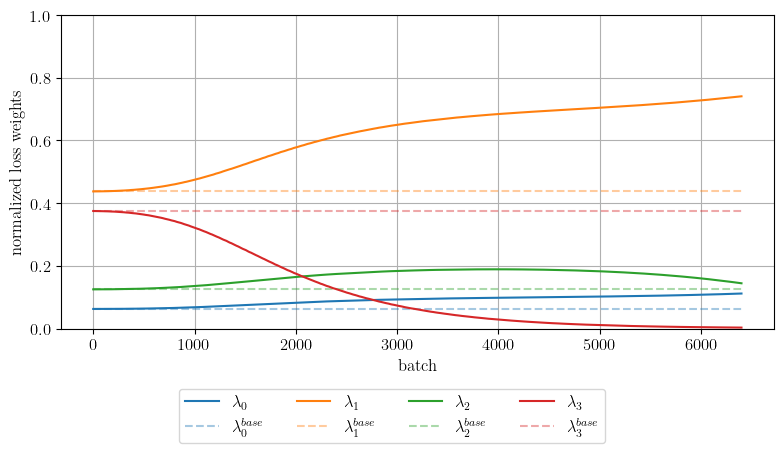

In [6]:
import matplotlib.pyplot as plt

# Kichler balancing factors (default settings, alpha=1, beta=2k/d^2) as reference
kichler_wL0 = 1
kichler_wL1 = ref_model.n_dims
kichler_wL2 = 2*k
kichler_wL3 = 6*(k**2)
c = 1 + ref_model.n_dims + 2*k
if variant == "3rdBatchSVD":
    c += 6*(k**2)
kichler_wLi = {
    0: kichler_wL0 / c,
    1: kichler_wL1 / c,
    2: kichler_wL2 / c,
    3: kichler_wL3 / c
}


ws = jnp.array([iteration_datas[t]["eff_w_norm"] for t in range(len(iteration_datas))])
active = (ws[0] != 0).astype(int)
ws = ws.T

fig = plt.figure(figsize=(8,4))

for i, v in enumerate(active):
    if v:
        plt.plot(ws[i], label=f"$\lambda_{i}$")
        current_color = plt.gca().lines[-1].get_color()
        
        plt.hlines(y=kichler_wLi[i], xmin=0, xmax=len(ws[i]), linestyles='dashed', colors=current_color, label=f"$\lambda_{i}^{{base}}$", alpha=0.4)
        
plt.xlabel("batch")
plt.ylabel("normalized loss weights")
plt.ylim(0, 1)
#plt.ylim(0.33, 0.34)
#plt.title("learned loss balancing weights", y=-0.2)
plt.grid(True)
# legend on the left
#plt.legend(loc='upper left')


# Shared legend under all plots
fig.legend(
    #handles,
    #[variant_names[v] for v in variants],
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.15)
)

plt.tight_layout()
plt.show()



In [ ]:
import time
now = time.strftime("%d_%m_%H_%M")
fig.savefig(f"res/loss_weights_{now}.pdf", bbox_inches='tight')

# Bachelier Evaluation Scatter Plots

running variant value
Training for 100 epochs with 64 batches per epoch and batch size 128.
Test predictions shapes:
test_pred_ys shape:  (8192,)
test_pred_dys shape:  (8192, 7)
test_pred_ddys shape:  (8192, 7, 7)
test_pred_dddys shape:  (8192, 7, 7, 7)

test y error: 0.00749
test dy error: 0.00694
test ddy error: 0.00696
test dddy error: 0.00816


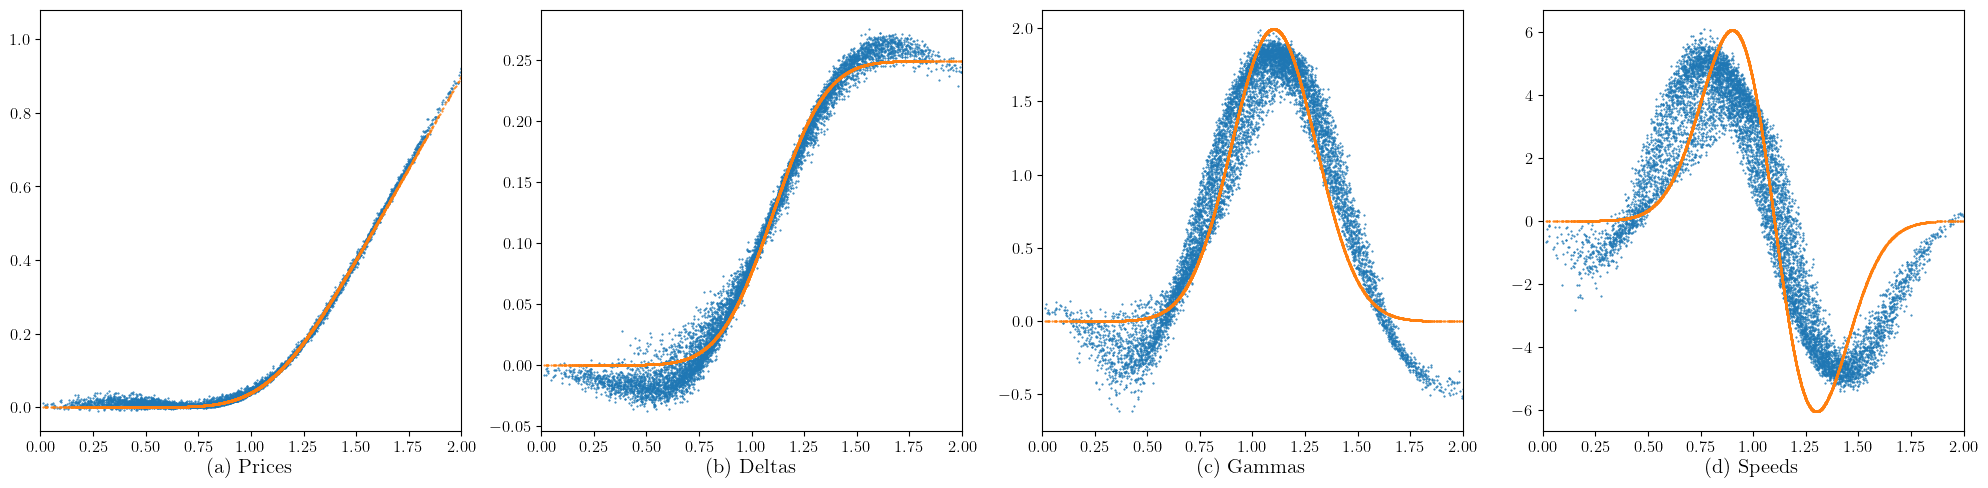

running variant 1st
Training for 100 epochs with 64 batches per epoch and batch size 128.
Test predictions shapes:
test_pred_ys shape:  (8192,)
test_pred_dys shape:  (8192, 7)
test_pred_ddys shape:  (8192, 7, 7)
test_pred_dddys shape:  (8192, 7, 7, 7)

test y error: 0.00216
test dy error: 0.00174
test ddy error: 0.00161
test dddy error: 0.00186


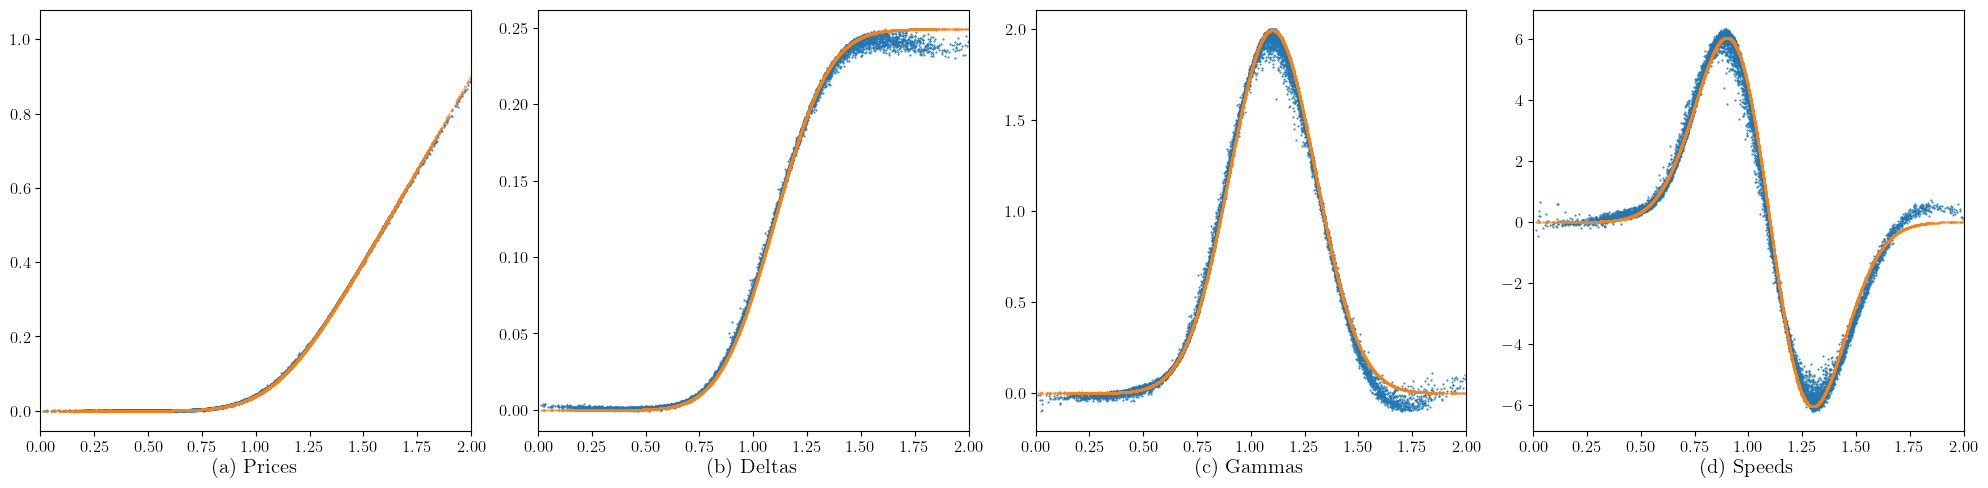

running variant batchSVD
Training for 100 epochs with 64 batches per epoch and batch size 128.
Test predictions shapes:
test_pred_ys shape:  (8192,)
test_pred_dys shape:  (8192, 7)
test_pred_ddys shape:  (8192, 7, 7)
test_pred_dddys shape:  (8192, 7, 7, 7)

test y error: 0.00055
test dy error: 0.00039
test ddy error: 0.00033
test dddy error: 0.00044


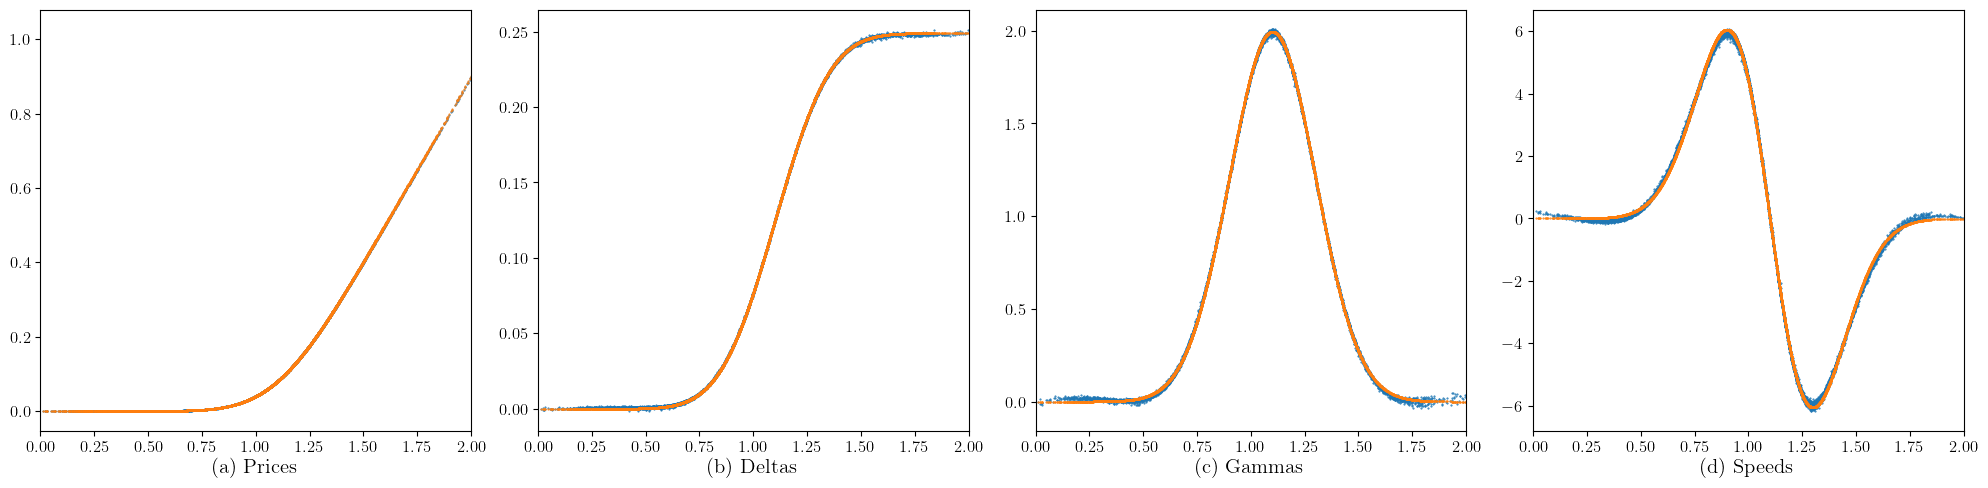

running variant 3rdBatchSVD
Training for 100 epochs with 64 batches per epoch and batch size 128.
Test predictions shapes:
test_pred_ys shape:  (8192,)
test_pred_dys shape:  (8192, 7)
test_pred_ddys shape:  (8192, 7, 7)
test_pred_dddys shape:  (8192, 7, 7, 7)

test y error: 0.00260
test dy error: 0.00094
test ddy error: 0.00041
test dddy error: 0.00042


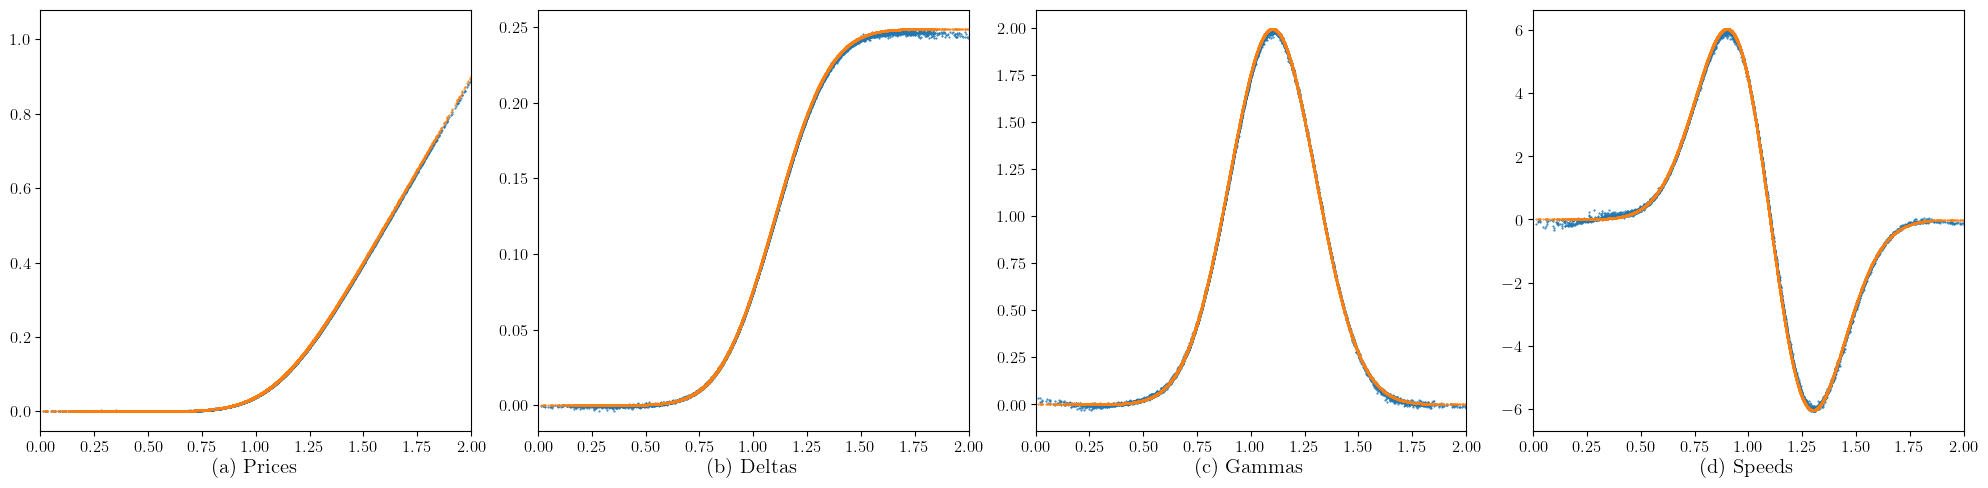

In [ ]:
import time

main_key = jrandom.PRNGKey(42)

n_epochs = 100
n_batches_per_epoch = 64#32#8#32 # 32
BATCH_SIZE = 128#256#16 #256 # 256

lr = 1e-3


# reference model
key, subkey = jax.random.split(main_key)
ref_model, test_set = make_bachelier(subkey, test_set_order=3, n_paths=0)

k = 1
streaming_r = 2

oversamppling_p = streaming_r - k
power_iteration_q = 0

learnable_loss_weights = True

do_approx_metrics = False # set to False for accurate time per batch measurement
do_test_eval = False


data = {}
for variant in ["value", "1st", "batchSVD", "3rdBatchSVD"]:
#for variant in ["value", "1st", "random", "pcady", "batchSVD", "streaming", "fullHessian", "3rdBatchSVD"]:
    print("running variant", variant)

    # nn model
    key, subkey = jax.random.split(key)
    input_dims = ref_model.n_dims
    mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=4, activation=jax.nn.silu)
    mlp = init_linear_weight(mlp, trunc_init, subkey)
    surrogate_model = mlp
    
    # sketch
    sketch = None
    if variant == "streaming":
        key, subkey = jax.random.split(key)
        sketch = StreamingHessianSketch(
                    ref_model=ref_model,
                    r=streaming_r,
                    k=k, 
                    key=subkey)
    
    
    
    optim = optax.adam(learning_rate=lr)
    
    
    surrogate_model, iteration_datas, sketch, avg_time_per_batch = train(
                            model = surrogate_model, 
                            test_data=test_set,
                            optim=optim, 
                            n_epochs=n_epochs,
                            n_batches_per_epoch=n_batches_per_epoch,
                            batch_size=BATCH_SIZE,
                            ref_model=ref_model,
                            sketch=sketch,
                            variant=variant,
                            k=k,
                            p=oversamppling_p,
                            q=power_iteration_q,
                            learnable_loss_weights=learnable_loss_weights,
                            do_approx_metrics=do_approx_metrics,
                            do_test_eval=do_test_eval
                            )
    

    from diff_ml.utils import rmse
    # eval price predictions
    test_pred_ys, test_pred_dys = vmap(jax.value_and_grad(surrogate_model))(test_set.x)
    test_pred_ddys = vmap(jax.hessian(MakeScalar(surrogate_model)))(test_set.x)
    test_pred_ddys = test_pred_ddys.reshape(test_set.ddy.shape)
    test_pred_dddys = vmap(jax.jacfwd(jax.hessian(MakeScalar(surrogate_model))))(test_set.x)
    test_pred_dddys = test_pred_dddys.reshape(test_set.dddy.shape)

    print("Test predictions shapes:")
    print("test_pred_ys shape: ", test_pred_ys.shape)
    print("test_pred_dys shape: ", test_pred_dys.shape)
    print("test_pred_ddys shape: ", test_pred_ddys.shape)
    print("test_pred_dddys shape: ", test_pred_dddys.shape)

    print("")
    y_error = rmse(test_pred_ys, test_set.y)
    dy_error = rmse(test_pred_dys, test_set.dy)
    ddy_error = rmse(test_pred_ddys, test_set.ddy)
    dddy_error = rmse(test_pred_dddys, test_set.dddy)

    print(f"test y error: {y_error:.5f}")
    print(f"test dy error: {dy_error:.5f}")
    print(f"test ddy error: {ddy_error:.5f}")
    print(f"test dddy error: {dddy_error:.5f}")

    fig = ref_model.plot_eval(test_pred_ys, test_pred_dys, test_pred_ddys, test_pred_dddys, test_set)
    
    now = time.strftime("%d%m_%H:%M")
    fig.savefig(f"res/eval_plots/eval_bachelier_{variant}_{now}.pdf", bbox_inches='tight')



